# Simplified Attention Mechanism

In [2]:
import torch

inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89], #word1
        [0.55, 0.87, 0.66], #word2
        [0.57, 0.85, 0.64], #word3
        [0.22, 0.58, 0.33], #word4
        [0.77, 0.25, 0.10], #word5
        [0.05, 0.80, 0.55]  #word6

    ]
)

In [4]:
query = inputs[1]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(query, x_i)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [5]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention Weights: ", attn_weights_2_tmp)
print("Sum of Attention Weights: ", attn_weights_2_tmp.sum())

Attention Weights:  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum of Attention Weights:  tensor(1.0000)


In [6]:
def softmax_navie(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_navie = softmax_navie(attn_scores_2)

print("Attention Weights (Naive Softmax): ", attn_weights_2_navie)
print("Sum of Attention Weights (Naive Softmax): ", attn_weights_2_navie.sum())


## The Context vector Z(2) is calculated as a weighted sum of all input vectors

Attention Weights (Naive Softmax):  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum of Attention Weights (Naive Softmax):  tensor(1.)


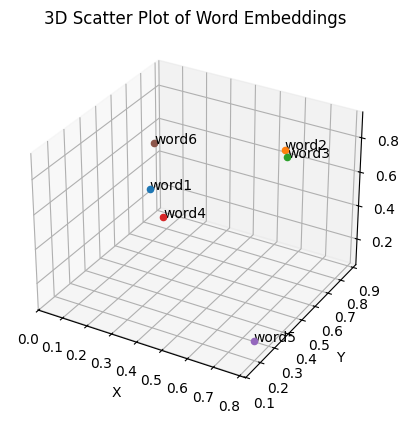

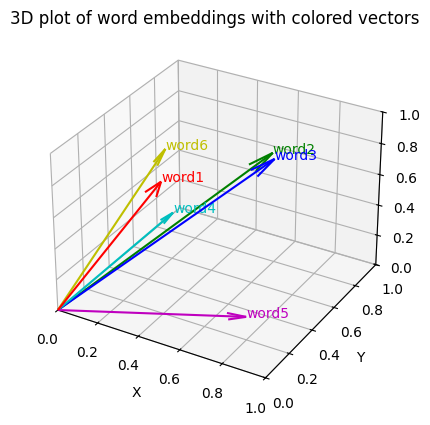

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

words = ['word1', 'word2', 'word3', 'word4', 'word5', 'word6']

x_cords = inputs[:, 0].numpy()
y_cords = inputs[:, 1].numpy()
z_cords = inputs[:, 2].numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for x, y, z, word in zip(x_cords, y_cords, z_cords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.title("3D Scatter Plot of Word Embeddings")
plt.show()


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c', 'm', 'y']

for x,y,z, word, color in zip(x_cords, y_cords, z_cords, words, colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.1)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])
plt.title("3D plot of word embeddings with colored vectors")
plt.show()

In [12]:
## Dot product for all possible parirs
attn_scores = torch.empty(inputs.shape[0], inputs.shape[0])

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print("Attention Scores Matrix: \n", attn_scores)

Attention Scores Matrix: 
 tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [13]:
attn_scores = inputs @ inputs.T
print("Attention Scores Matrix (using matrix multiplication): \n", attn_scores)

Attention Scores Matrix (using matrix multiplication): 
 tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [14]:
## Normalization of attention scores
attn_weights = torch.softmax(attn_scores, dim=-1)
print("Attention Weights Matrix: \n", attn_weights)

Attention Weights Matrix: 
 tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [16]:
row_2_sum = attn_weights[2].sum()
print("Sum of attention weights for row 2: ", row_2_sum)

Sum of attention weights for row 2:  tensor(1.0000)


# Self Attention with Trainable Weights

In [18]:
# Input Embedding Size
d_in = 3
# Output Embedding Size
d_out = 2

In [19]:
torch.manual_seed(123)

W_query = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=True)
W_key = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=True)
W_value = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=True)

In [20]:
query_2 = inputs[2] @ W_query
key_2 = inputs[2] @ W_key
value_2 = inputs[2] @ W_value

print("Query Vector for word3: ", query_2)
print("Key Vector for word3: ", key_2)
print("Value Vector for word3: ", value_2)

Query Vector for word3:  tensor([-1.1438, -0.0018], grad_fn=<SqueezeBackward4>)
Key Vector for word3:  tensor([-0.1443, -0.7728], grad_fn=<SqueezeBackward4>)
Value Vector for word3:  tensor([0.4091, 0.6390], grad_fn=<SqueezeBackward4>)


In [26]:
# attn_score_3 = torch.dot(query_2, key_2)
attn_score_3 = query_2 @ key_2.T
print("Attention score for word3: ", attn_score_3)

Attention score for word3:  tensor(0.1665, grad_fn=<DotBackward0>)


In [21]:
Keys = inputs @ W_key
Values = inputs @ W_value
Querys = inputs @ W_query

print("Keys Matrix: \n", Keys)
print("Values Matrix: \n", Values)
print("Querys Matrix: \n", Querys)

Keys Matrix: 
 tensor([[-0.1823, -0.6888],
        [-0.1142, -0.7676],
        [-0.1443, -0.7728],
        [ 0.0434, -0.3580],
        [-0.6467, -0.6476],
        [ 0.3262, -0.3395]], grad_fn=<MmBackward0>)
Values Matrix: 
 tensor([[ 0.1196, -0.3566],
        [ 0.4107,  0.6274],
        [ 0.4091,  0.6390],
        [ 0.2436,  0.4182],
        [ 0.2653,  0.6668],
        [ 0.2728,  0.3242]], grad_fn=<MmBackward0>)
Querys Matrix: 
 tensor([[-1.1686,  0.2019],
        [-1.1729, -0.0048],
        [-1.1438, -0.0018],
        [-0.6339, -0.0439],
        [-0.2979,  0.0535],
        [-0.9596, -0.0712]], grad_fn=<MmBackward0>)


In [27]:
attn_scores = Querys @ Keys.T
print("Attention Scores Matrix: \n", attn_scores)

Attention Scores Matrix: 
 tensor([[ 0.0740, -0.0216,  0.0126, -0.1230,  0.6250, -0.4498],
        [ 0.2172,  0.1376,  0.1730, -0.0491,  0.7616, -0.3809],
        [ 0.2098,  0.1320,  0.1665, -0.0489,  0.7408, -0.3725],
        [ 0.1458,  0.1061,  0.1254, -0.0118,  0.4384, -0.1919],
        [ 0.0175, -0.0071,  0.0017, -0.0321,  0.1580, -0.1153],
        [ 0.2240,  0.1642,  0.1935, -0.0161,  0.6667, -0.2888]],
       grad_fn=<MmBackward0>)


Dividing By SQRT
- For stability in learning
- To make varience of the dot product more stable

In [29]:
d_k = Keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores / torch.sqrt(torch.tensor(d_k, dtype=torch.float32)), dim=-1)
print("Attention Weights Matrix (Scaled): \n", attn_weights_2)

Attention Weights Matrix (Scaled): 
 tensor([[0.1687, 0.1576, 0.1615, 0.1467, 0.2490, 0.1165],
        [0.1704, 0.1611, 0.1652, 0.1412, 0.2505, 0.1117],
        [0.1704, 0.1613, 0.1653, 0.1419, 0.2481, 0.1129],
        [0.1704, 0.1656, 0.1679, 0.1524, 0.2095, 0.1342],
        [0.1680, 0.1651, 0.1661, 0.1622, 0.1856, 0.1529],
        [0.1711, 0.1640, 0.1675, 0.1444, 0.2340, 0.1191]],
       grad_fn=<SoftmaxBackward0>)


## Class Implementation of Self Attention Layer

In [30]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.randn(d_in, d_out))
        self.W_key = nn.Parameter(torch.randn(d_in, d_out))
        self.W_value = nn.Parameter(torch.randn(d_in, d_out))

    def forward(self, x):
        Keys = x @ self.W_key
        Values = x @ self.W_value
        Querys = x @ self.W_query

        attn_scores = Querys @ Keys.T
        attn_weights = torch.softmax(
            attn_scores / Keys.shape[-1] ** 0.5, dim=-1
        )
        context_vectors = attn_weights @ Values
        return context_vectors

In [31]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
context_vectors_v1 = sa_v1(inputs)
print("Context Vectors from Self-Attention v1: \n", context_vectors_v1)

Context Vectors from Self-Attention v1: 
 tensor([[0.2845, 0.4071],
        [0.2854, 0.4081],
        [0.2854, 0.4075],
        [0.2864, 0.3974],
        [0.2863, 0.3910],
        [0.2860, 0.4039]], grad_fn=<MmBackward0>)


In [32]:
## Using nn.Linear instead of nn.Parameter, Since nn.Linear has optimized wight initialization and more stable and effective model training.

class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        
    def forward(self, x):
        Keys = self.W_key(x)
        Values = self.W_value(x)
        Querys = self.W_query(x)

        attn_scores = Querys @ Keys.T
        attn_weights = torch.softmax(
            attn_scores / Keys.shape[-1] ** 0.5, dim=-1
        )
        context_vector = attn_weights @ Values
        return context_vector

In [33]:
torch.manual_seed(12)
sa_v2 = SelfAttention_v2(d_in, d_out)
context_vectors_v2 = sa_v2(inputs)
print("Context Vectors from Self-Attention v2: \n", context_vectors_v2)

Context Vectors from Self-Attention v2: 
 tensor([[0.1650, 0.3532],
        [0.1653, 0.3548],
        [0.1652, 0.3545],
        [0.1649, 0.3514],
        [0.1644, 0.3474],
        [0.1652, 0.3542]], grad_fn=<MmBackward0>)


# Casual(Masked) Attention

In [34]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(
    attn_scores / keys.shape[-1]**0.5, dim=-1
)
print("Attention Weights Matrix from Self-Attention v2: \n", attn_weights)

Attention Weights Matrix from Self-Attention v2: 
 tensor([[0.1543, 0.1686, 0.1682, 0.1718, 0.1616, 0.1754],
        [0.1499, 0.1691, 0.1687, 0.1735, 0.1610, 0.1777],
        [0.1504, 0.1691, 0.1686, 0.1733, 0.1612, 0.1774],
        [0.1565, 0.1682, 0.1679, 0.1708, 0.1634, 0.1732],
        [0.1639, 0.1670, 0.1670, 0.1677, 0.1662, 0.1681],
        [0.1512, 0.1690, 0.1686, 0.1730, 0.1613, 0.1769]],
       grad_fn=<SoftmaxBackward0>)


In [35]:
context_length = attn_scores.shape[0]
torch.ones(context_length, context_length)

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

In [36]:
mask_simple = torch.tril(torch.ones(context_length, context_length))
print("Simple Causal Mask: \n", mask_simple)

Simple Causal Mask: 
 tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [45]:
## Upper Triangular and Lower Triangular Matrix
mask_lower = torch.tril(torch.ones(context_length, context_length),diagonal=1)
mask_upper = torch.triu(torch.ones(context_length, context_length), diagonal=1)
print("Lower Triangular Mask: \n", mask_lower)
print("Upper Triangular Mask: \n", mask_upper)

Lower Triangular Mask: 
 tensor([[1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])
Upper Triangular Mask: 
 tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])


In [38]:
masked_simple = attn_weights*mask_simple
print("Masked Attention Scores (Simple Causal Mask): \n", masked_simple)

Masked Attention Scores (Simple Causal Mask): 
 tensor([[0.1543, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1499, 0.1691, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1504, 0.1691, 0.1686, 0.0000, 0.0000, 0.0000],
        [0.1565, 0.1682, 0.1679, 0.1708, 0.0000, 0.0000],
        [0.1639, 0.1670, 0.1670, 0.1677, 0.1662, 0.0000],
        [0.1512, 0.1690, 0.1686, 0.1730, 0.1613, 0.1769]],
       grad_fn=<MulBackward0>)


In [39]:
## Renormalization of masked attention scores
masked_attn_weights = masked_simple / masked_simple.sum(dim=-1, keepdim=True)
print("Renormalized Masked Attention Weights: \n", masked_attn_weights)

Renormalized Masked Attention Weights: 
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4699, 0.5301, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3081, 0.3464, 0.3455, 0.0000, 0.0000, 0.0000],
        [0.2359, 0.2535, 0.2531, 0.2574, 0.0000, 0.0000],
        [0.1970, 0.2008, 0.2007, 0.2016, 0.1998, 0.0000],
        [0.1512, 0.1690, 0.1686, 0.1730, 0.1613, 0.1769]],
       grad_fn=<DivBackward0>)


In [41]:
# While using Softmax layer to convert each row into a probability distribution, -inf means 0 probability.
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print("Masked Attention Scores (using -inf for masked positions): \n", masked)

Masked Attention Scores (using -inf for masked positions): 
 tensor([[-0.1212,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.1681,  0.0026,    -inf,    -inf,    -inf,    -inf],
        [-0.1631,  0.0025, -0.0011,    -inf,    -inf,    -inf],
        [-0.1005,  0.0014, -0.0008,  0.0230,    -inf,    -inf],
        [-0.0275, -0.0006, -0.0009,  0.0051, -0.0073,    -inf],
        [-0.1546,  0.0027, -0.0007,  0.0362, -0.0629,  0.0679]],
       grad_fn=<MaskedFillBackward0>)


In [42]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
print("Masked Attention Weights (using -inf for masked positions): \n", attn_weights)

Masked Attention Weights (using -inf for masked positions): 
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4699, 0.5301, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3081, 0.3464, 0.3455, 0.0000, 0.0000, 0.0000],
        [0.2359, 0.2535, 0.2531, 0.2574, 0.0000, 0.0000],
        [0.1970, 0.2008, 0.2007, 0.2016, 0.1998, 0.0000],
        [0.1512, 0.1690, 0.1686, 0.1730, 0.1613, 0.1769]],
       grad_fn=<SoftmaxBackward0>)


In [43]:
## Dropout
dropout = nn.Dropout(p=0.5)
print("Attention Weights after applying Dropout: \n", dropout(attn_weights))

Attention Weights after applying Dropout: 
 tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.9397, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.6910, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.5070, 0.5063, 0.0000, 0.0000, 0.0000],
        [0.3940, 0.4016, 0.4015, 0.0000, 0.0000, 0.0000],
        [0.3024, 0.3379, 0.3371, 0.0000, 0.3226, 0.0000]],
       grad_fn=<MulBackward0>)


## Class of Casual Attention

In [72]:
import torch.nn as nn

class CasualAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(p=dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1).bool())

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        Keys = self.W_key(x)
        Values = self.W_value(x)
        Querys = self.W_query(x)
        attn_scores = Querys @ Keys.transpose(-2, -1)
        attn_scores = attn_scores.masked_fill(
            self.mask[:num_tokens, :num_tokens].unsqueeze(0), -torch.inf
        )
        attn_weights = torch.softmax(attn_scores / self.d_out**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        context_vector = attn_weights @ Values
        return context_vector
        

In [68]:
torch.manual_seed(123)
context_length = inputs.shape[0]
causal_attn = CasualAttention(d_in, d_out, context_length, dropout=0)
context_vector = causal_attn(inputs.unsqueeze(0))
print("Context Vector from Casual Attention: \n", context_vector)

Context Vector from Casual Attention: 
 tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


# Multi-head Attention Mechanism

In [73]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [
                CasualAttention(d_in, d_out, context_length, dropout, qkv_bias)
                for _ in range(num_heads)
            ]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [70]:
batch = torch.stack((inputs, inputs), dim=0)
print("Batch Shape: \n", batch.shape)

Batch Shape: 
 torch.Size([2, 6, 3])


In [75]:
torch.manual_seed(123)
context_length = inputs.shape[0]
d_in, d_out = 3, 2
multi_head_attn = MultiHeadAttentionWrapper(d_in, d_out, context_length, dropout=0, num_heads=2)
context_vector_multi_head = multi_head_attn(batch)
print("Context Vector from Multi-Head Attention: \n", context_vector_multi_head)

Context Vector from Multi-Head Attention: 
 tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)


# Multi-Head Attention

In [76]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(p=dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1).bool())


    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        attn_scores = queries @ keys.transpose(-2, -1)

        mask_bool = self.mask[:num_tokens, :num_tokens]
        attn_scores.masked_fill(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vector = (attn_weights @ values).transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)
        return context_vector

In [77]:
print(batch.shape)

torch.Size([2, 6, 3])


In [78]:
batch_size, num_tokens, d_in = batch.shape
d_out = 6

multi_head_attn_v2 = MultiHeadAttention(d_in, d_out, context_length, dropout=0, num_heads=2)
context_vector_multi_head_v2 = multi_head_attn_v2(batch)
print("Context Vector from Multi-Head Attention v2: \n", context_vector_multi_head_v2)
print("Shape of Context Vector from Multi-Head Attention v2: \n", context_vector_multi_head_v2.shape)

Context Vector from Multi-Head Attention v2: 
 tensor([[[-0.3228, -0.1582,  0.3755,  0.0471, -0.4489,  0.4989],
         [-0.3285, -0.1529,  0.3779,  0.0475, -0.4477,  0.4986],
         [-0.3284, -0.1529,  0.3778,  0.0474, -0.4477,  0.4986],
         [-0.3258, -0.1527,  0.3715,  0.0470, -0.4489,  0.4989],
         [-0.3251, -0.1545,  0.3716,  0.0470, -0.4476,  0.4979],
         [-0.3267, -0.1521,  0.3733,  0.0471, -0.4492,  0.4994]],

        [[-0.3228, -0.1582,  0.3755,  0.0471, -0.4489,  0.4989],
         [-0.3285, -0.1529,  0.3779,  0.0475, -0.4477,  0.4986],
         [-0.3284, -0.1529,  0.3778,  0.0474, -0.4477,  0.4986],
         [-0.3258, -0.1527,  0.3715,  0.0470, -0.4489,  0.4989],
         [-0.3251, -0.1545,  0.3716,  0.0470, -0.4476,  0.4979],
         [-0.3267, -0.1521,  0.3733,  0.0471, -0.4492,  0.4994]]],
       grad_fn=<ViewBackward0>)
Shape of Context Vector from Multi-Head Attention v2: 
 torch.Size([2, 6, 6])
